In [5]:
import pandas as pd
import numpy as np


df_hist = pd.read_csv("nba_team_reference.csv")
# This is extra data for the 2025-2026 season

# df_new_full = pd.read_csv("nba_2025_26_simulated.csv")

# df_hist['game_date'] = pd.to_datetime(df_hist['game_date'])
# df_new_full['game_date'] = pd.to_datetime(df_new_full['game_date'])

# Last 30 games are fot a "future" test 
# df_new_trimmed = df_new_full.iloc[:-30].copy()
# df_future = df_new_full.iloc[-30:].copy()

df = pd.concat([df_hist], ignore_index=True)

# Standardized data
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values('game_date').reset_index(drop=True)

# Verify the timeline
print(f"Total games: {len(df)}")

Total games: 9090


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

team_stats = {team: {
    'games': 0, 
    'wins': 0, 
    'total_margin': 0, 
    'last_date': None, 
    'recent': [], 
    'ema_offense': 100.0, 
    'ema_defense': 100.0, 
    'opp_win_sum': 0,
    'possessions': 0,
    'pts_scored': 0,
    'pts_allowed': 0
} for team in set(df['team_abbreviation_home']) | set(df['team_abbreviation_away'])}

features, targets = [], []
alpha_ema = 0.15

def get_stats(t, date):
    s = team_stats[t]
    win_pct = s['wins'] / s['games'] if s['games'] > 0 else 0.5
    avg_margin = s['total_margin'] / s['games'] if s['games'] > 0 else 0
    recent_margin = np.mean(s['recent']) if s['recent'] else 0
    rest = min((date - s['last_date']).days, 7) if s['last_date'] else 7
    sos = s['opp_win_sum'] / s['games'] if s['games'] > 0 else 0.5
    
    off_eff = (s['pts_scored'] / s['possessions'] * 100) if s['possessions'] > 0 else 110.0
    def_eff = (s['pts_allowed'] / s['possessions'] * 100) if s['possessions'] > 0 else 110.0
    net_rating = off_eff - def_eff
    
    return win_pct, avg_margin, recent_margin, rest, sos, s['ema_offense'], s['ema_defense'], net_rating

for row in df.itertuples():
    h, a = row.team_abbreviation_home, row.team_abbreviation_away
    
    h_win_pct_pre = team_stats[h]['wins'] / team_stats[h]['games'] if team_stats[h]['games'] > 0 else 0.5
    a_win_pct_pre = team_stats[a]['wins'] / team_stats[a]['games'] if team_stats[a]['games'] > 0 else 0.5
    
    h_s, a_s = get_stats(h, row.game_date), get_stats(a, row.game_date)
    
    features.append([
        h_s[0]-a_s[0], h_s[1]-a_s[1], h_s[2]-a_s[2], 
        h_s[3]-a_s[3], h_s[4]-a_s[4], h_s[5]-a_s[5], h_s[6]-a_s[6], h_s[7]-a_s[7]
    ])
    
    win_ratio = row.pts_home / (row.pts_home + row.pts_away) if (row.pts_home + row.pts_away) > 0 else 0.5
    targets.append(win_ratio)
    
    margin = row.pts_home - row.pts_away
    
    for t, m, pts_in, pts_out, opp_pre_win in [
        (h, margin, row.pts_home, row.pts_away, a_win_pct_pre), 
        (a, -margin, row.pts_away, row.pts_home, h_win_pct_pre)
    ]:
        s = team_stats[t]
        s['ema_offense'] = (pts_in * alpha_ema) + (s['ema_offense'] * (1 - alpha_ema))
        s['ema_defense'] = (pts_out * alpha_ema) + (s['ema_defense'] * (1 - alpha_ema))
        
        s['games'] += 1
        s['wins'] += 1 if m > 0 else 0
        s['total_margin'] += m
        s['last_date'] = row.game_date
        s['recent'] = (s['recent'] + [m])[-10:]
        s['opp_win_sum'] += opp_pre_win
        
        s['pts_scored'] += pts_in
        s['pts_allowed'] += pts_out
        s['possessions'] += 100

x, y = np.array(features), np.array(targets)
split_idx = int(len(x) * 0.74)

train_weights = np.linspace(0.5, 1.0, split_idx)

model = make_pipeline(StandardScaler(), Ridge(alpha=20))
model.fit(x[:split_idx], y[:split_idx], ridge__sample_weight=train_weights)

predictions = model.predict(x[split_idx:])
y_test_actual = y[split_idx:]

accuracy = ((predictions > 0.5) == (y_test_actual > 0.5)).mean()

print(f"Prediction Accuracy: {accuracy:.2%}")

Prediction Accuracy: 64.42%


Starting Bankroll: $10,000
Final Bankroll: $15,890.57
Total Profit: $5,890.57
Season ROI: 5890.57%
Prediction Accuracy: 54.31%
Brier Score (Mean Squared Error): 0.2467
Total Bets Placed: 2364


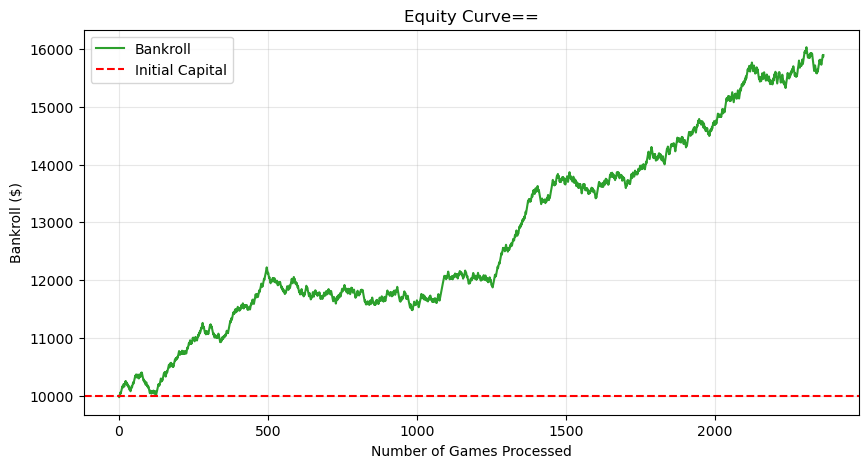

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

ridge_train_idx = int(split_idx * 0.7)
calib_x = x[ridge_train_idx:split_idx]
calib_y = (y[ridge_train_idx:split_idx] > 0.5).astype(int)

model.fit(x[:ridge_train_idx], y[:ridge_train_idx], ridge__sample_weight=train_weights[:ridge_train_idx])

calib_preds_raw = model.predict(calib_x).reshape(-1, 1)
calibrator = LogisticRegression().fit(calib_preds_raw, calib_y)

initial_bankroll = 10000
bankroll = initial_bankroll
paperbet_odds = 1.91 
b = paperbet_odds - 1

test_preds_raw = model.predict(x[split_idx:]).reshape(-1, 1)
probs = calibrator.predict_proba(test_preds_raw)[:, 1]
y_test_actual = y[split_idx:]

bankroll_history = [initial_bankroll]
wins = 0
total_bets = 0

for i, p in enumerate(probs):
    is_home_bet = p > 0.5
    actual_home_win = y_test_actual[i] > 0.5
    win_event = (is_home_bet == actual_home_win)
    
    win_prob = p if is_home_bet else (1 - p)
    q = 1 - win_prob
    kelly_f = ((b * win_prob) - q) / b
    
    stake_pct = max(0, kelly_f * 0.025)
    bet_amount = bankroll * stake_pct
    
    if bet_amount > 0:
        total_bets += 1
        if win_event:
            bankroll += (bet_amount * b)
            wins += 1
        else:
            bankroll -= bet_amount
    
    bankroll_history.append(bankroll)

profit = bankroll - initial_bankroll
accuracy = ( (probs > 0.5) == (y_test_actual > 0.5) ).mean()
brier = brier_score_loss((y_test_actual > 0.5).astype(int), probs)

print(f"Starting Bankroll: ${initial_bankroll:,}")
print(f"Final Bankroll: ${bankroll:,.2f}")
print(f"Total Profit: ${profit:,.2f}")
print(f"Season ROI: {(profit/initial_bankroll)*100:.2%}")
print(f"Prediction Accuracy: {accuracy:.2%}")
print(f"Brier Score (Mean Squared Error): {brier:.4f}")
print(f"Total Bets Placed: {total_bets}")

plt.figure(figsize=(10, 5))
plt.plot(bankroll_history, color='#2ca02c', label='Bankroll')
plt.axhline(y=initial_bankroll, color='r', linestyle='--', label='Initial Capital')
plt.title('Equity Curve==')
plt.xlabel('Number of Games Processed')
plt.ylabel('Bankroll ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

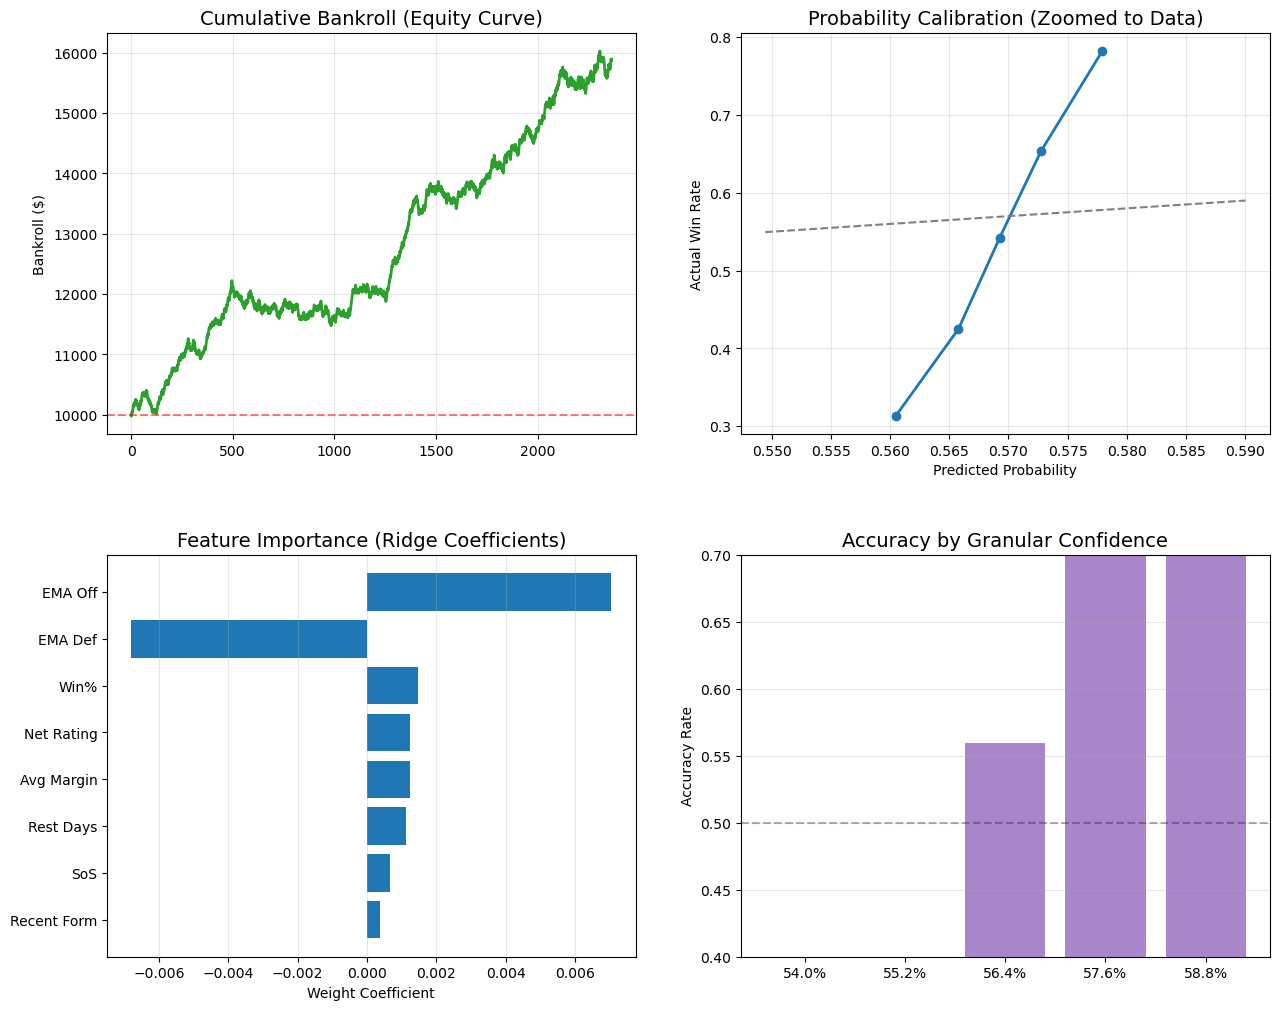

In [8]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

axs[0, 0].plot(bankroll_history, color='#2ca02c', linewidth=2)
axs[0, 0].axhline(y=initial_bankroll, color='red', linestyle='--', alpha=0.5)
axs[0, 0].set_title('Cumulative Bankroll (Equity Curve)', fontsize=14)
axs[0, 0].set_ylabel('Bankroll ($)')
axs[0, 0].grid(True, alpha=0.3)


prob_true, prob_pred = calibration_curve((y_test_actual > 0.5).astype(int), probs, n_bins=5, strategy='quantile')
axs[0, 1].plot(prob_pred, prob_true, marker='o', linewidth=2)
axs[0, 1].plot([min(probs), max(probs)], [min(probs), max(probs)], linestyle='--', color='gray') # Zoomed diagonal
axs[0, 1].set_title('Probability Calibration (Zoomed to Data)', fontsize=14)
axs[0, 1].set_xlabel('Predicted Probability')
axs[0, 1].set_ylabel('Actual Win Rate')
axs[0, 1].grid(True, alpha=0.3)

feature_names = ['Win%', 'Avg Margin', 'Recent Form', 'Rest Days', 'SoS', 'EMA Off', 'EMA Def', 'Net Rating']
coefs = model.named_steps['ridge'].coef_
sorted_idx = np.argsort(np.abs(coefs))
axs[1, 0].barh(np.array(feature_names)[sorted_idx], coefs[sorted_idx], color='#1f77b4')
axs[1, 0].set_title('Feature Importance (Ridge Coefficients)', fontsize=14)
axs[1, 0].set_xlabel('Weight Coefficient')
axs[1, 0].grid(axis='x', alpha=0.3)


bins = np.linspace(np.floor(min(probs)*100)/100, np.ceil(max(probs)*100)/100, 6)
bin_accuracy = []
bin_labels = []
for i in range(len(bins)-1):
    mask = (probs >= bins[i]) & (probs < bins[i+1])
    if mask.any():
        acc = ((probs[mask] > 0.5) == (y_test_actual[mask] > 0.5)).mean()
        bin_accuracy.append(acc)
    else:
        bin_accuracy.append(0)
    bin_labels.append(f"{bins[i]:.1%}")

axs[1, 1].bar(bin_labels, bin_accuracy, color='#9467bd', alpha=0.8)
axs[1, 1].axhline(y=0.5, color='black', linestyle='--', alpha=0.3)
axs[1, 1].set_title('Accuracy by Granular Confidence', fontsize=14)
axs[1, 1].set_ylabel('Accuracy Rate')
axs[1, 1].set_ylim(0.4, 0.7)
axs[1, 1].grid(axis='y', alpha=0.3)

plt.show()

In [1]:
# # Static model for testing future bets (doesn't update with time) -- this si based on randomly generated test data

# future_bankroll = bankroll  
# future_history = [future_bankroll]
# future_preds = []
# future_actuals = []

# b = 1.91 - 1 

# print(f"Starting Static Future Test: ${future_bankroll:,.2f}")

# for row in df_future.itertuples():
#     h, a = row.team_abbreviation_home, row.team_abbreviation_away
    
#     h_s = get_stats(h, row.game_date)
#     a_s = get_stats(a, row.game_date)
    
#     feat = np.array([h_s[i] - a_s[i] for i in range(7)]).reshape(1, -1)
    
#     raw_val = model.predict(feat)
#     prob = calibrator.predict_proba(raw_val.reshape(-1, 1))[0, 1]
    
#     is_home_bet = prob > 0.5
#     actual_home_win = row.pts_home > row.pts_away
#     win_event = (is_home_bet == actual_home_win)
    
#     win_prob = prob if is_home_bet else (1 - prob)
#     q = 1 - win_prob
#     kelly_f = ((b * win_prob) - q) / b
    
#     stake = max(0, future_bankroll * kelly_f * 0.025)
    
#     if stake > 0:
#         if win_event:
#             future_bankroll += (stake * b)
#         else:
#             future_bankroll -= stake
            
#     future_history.append(future_bankroll)
#     future_preds.append(int(is_home_bet))
#     future_actuals.append(int(actual_home_win))

# # 5. METRICS
# future_acc = (np.array(future_preds) == np.array(future_actuals)).mean()
# print(f"\n--- Static Performance (Last 30 Games) ---")
# print(f"Accuracy: {future_acc:.2%}")
# print(f"Net Profit: ${future_bankroll - bankroll:,.2f}")

In [12]:
import json
import numpy as np

def build_prob_matrix(model, calibrator, team_stats, teams):
    matrix = {}
    ref_date = df['game_date'].max()
    
    for home in teams:
        matrix[home] = {}
        for away in teams:
            if home == away:
                continue
            
            h_s = get_stats(home, ref_date)
            a_s = get_stats(away, ref_date)
            
            diffs = np.array([[h_s[i] - a_s[i] for i in range(8)]])
            
            raw_val = model.predict(diffs).reshape(-1, 1)
            prob = calibrator.predict_proba(raw_val)[0, 1]
            
            matrix[home][away] = round(float(prob), 4)
            
    return matrix

all_teams = sorted(list(team_stats.keys()))
prob_matrix = build_prob_matrix(model, calibrator, team_stats, all_teams)

with open("nba_probs.json", "w") as f:
    json.dump(prob_matrix, f, indent=2)